## Benchmarks

In [1]:
import sph_cupy
import sph # baseline
import sph_multiprocessing
import sph_core

[[ 0.20262504  0.12708993  0.03936404]
 [ 0.58161663  0.04282153 -0.12876747]
 [ 0.11285734  0.29377433 -0.11445015]
 ...
 [-0.59835171 -0.07789294 -0.05228875]
 [-0.50338322  0.15863895 -0.28661348]
 [ 0.23923893  0.16312656  0.51541201]]
------------
[[ 0.20262504  0.12708993  0.03936404]
 [ 0.58161663  0.04282153 -0.12876747]
 [ 0.11285734  0.29377433 -0.11445015]
 ...
 [-0.59835171 -0.07789294 -0.05228875]
 [-0.50338322  0.15863895 -0.28661348]
 [ 0.23923893  0.16312656  0.51541201]]
----------
[[ 0.20262504  0.12708993  0.03936404]
 [ 0.58161663  0.04282153 -0.12876747]
 [ 0.11285734  0.29377433 -0.11445015]
 ...
 [-0.59835171 -0.07789294 -0.05228875]
 [-0.50338322  0.15863895 -0.28661348]
 [ 0.23923893  0.16312656  0.51541201]]
mp:
True
True
cp:
True
True
cython:
True
True


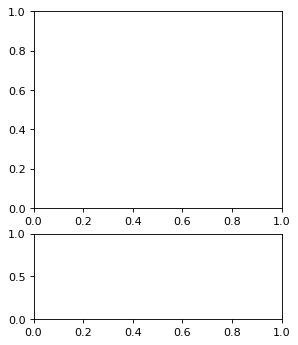

In [ ]:
# Vailidation tests
import numpy as np

N = 400

pos, vel = sph.main(400)
mp_pos, mp_vel = sph_multiprocessing.main(400)
cp_pos, cp_vel = sph_cupy.main(400)
cython_pos, cython_vel = sph_core.run_sph_cython(400)

print("mp:")
print(np.allclose(pos, mp_pos))
print(np.allclose(vel, mp_vel))
print("cp:")
print(np.allclose(pos, cp_pos))
print(np.allclose(vel, cp_vel))
print("cython:")
print(np.allclose(pos, cython_pos))
print(np.allclose(vel, cython_vel))



In [2]:
import matplotlib.pyplot as plt

def benchmark(funcs, Ns):
    benchmark_data = {}
    for func in funcs:
        ts_avg = []
        for n in Ns:
            t = %timeit -o func[0](n)
            ts_avg.append(t.average)
        
        benchmark_data[func[1]] = ts_avg
        
    return benchmark_data

def plot_benchmarks(benchmark_data, Ns):
    plt.close("all")
    plt.title("Benchmarks")
    for t in benchmark_data:
        plt.plot(Ns, benchmark_data[t], marker='o', label=t)
        plt.xlabel("Number of particles")
        plt.legend()
        plt.grid(True)
        plt.ylabel("Average runtime")
        plt.yscale("log")
    plt.show()


In [3]:
# Speedup

def speedups(baseline, benchmark_data, indexes, Ns):
    baseline_benchmark = benchmark_data[baseline]
    speed_ups = {}
    for t in benchmark_data:
        if t == baseline:
            continue
        print(f"{t}:")
        for i in indexes:
            print(f"{Ns[i]}: {baseline_benchmark[i]/benchmark_data[t][i]}")
        print()
    
        


101 ms ± 3.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
301 ms ± 12.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.61 s ± 122 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
7.58 s ± 223 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
9.96 s ± 368 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
14.3 s ± 360 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
32.9 s ± 399 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1min 1s ± 1.03 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
382 ms ± 3.27 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
378 ms ± 4.15 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


/home/isakf/dev/kth/optimizations-of-sph/sph_cupy.py:195: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(4, 5), dpi=80)


378 ms ± 5.51 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
745 ms ± 5.89 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.35 s ± 19.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.04 s ± 30.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.79 s ± 136 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
8.52 s ± 225 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
933 ms ± 40.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.08 s ± 29.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.8 s ± 67.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.6 s ± 353 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
6.2 s ± 179 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
9.41 s ± 357 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
20.3 s ± 1.17 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
41.7 s ± 954 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
55 ms ± 1.99 ms per loop (mean ± std. dev. of 7 runs, 10 l

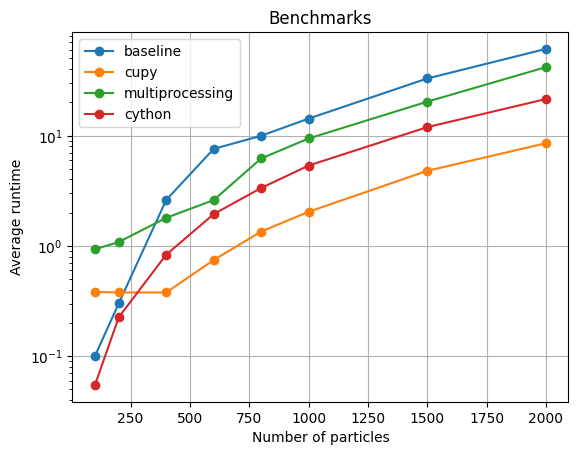

In [9]:
funcs = [(sph.main, "baseline"), (sph_cupy.main, "cupy"), (sph_multiprocessing.main, "multiprocessing"), (sph_core.run_sph_cython, "cython")]
Ns = [100, 200, 400, 600, 800, 1000, 1500, 2000]
benchmarks = benchmark(funcs, Ns)
plot_benchmarks(benchmarks, Ns)

In [20]:
print(benchmarks)
speedups("baseline", benchmarks, [2, 7], Ns)

{'baseline': [0.1007604560571573, 0.30136167899997546, 2.6087424258569496, 7.575709603999712, 9.964110858285494, 14.253626609714567, 32.926321447143245, 61.025389908714196], 'cupy': [0.3822368585712996, 0.37847583028555426, 0.37839434971439395, 0.7448273241430537, 1.3487808428568056, 2.038085920714366, 4.792839707714718, 8.52131376914258], 'multiprocessing': [0.933043869285549, 1.0848014101429726, 1.798489346857033, 2.602227570999925, 6.203381683714075, 9.41139440828608, 20.29511264728561, 41.725414660571396], 'cython': [0.05498144341425879, 0.2257008661425581, 0.8325531698574196, 1.9419309687140671, 3.3480544349999297, 5.350253641142834, 11.926974934428342, 21.437352901999994]}
cupy:
400: 6.894242548351969
2000: 7.161500158543582

multiprocessing:
400: 1.4505186980483826
2000: 1.4625472366217223

cython:
400: 3.1334244109643046
2000: 2.846684951621095

